# Thematic Alignment Analysis: Drug Safety Journal

Compact notebook for inspecting the outputs of the `src/` pipeline. The
implementation stays in `src/` and `scripts/`; this notebook only orchestrates
and previews already-computed results. Full methodology, citations, and the
reasoning behind every design choice are documented in the project log
(not included in this repository as a formal report, see `paper/` for the
final write-up).

## Setup

Run this notebook from the repository root (nlp-project/). Before running it, make sure the following scripts have already been run at least once, so their outputs exist on disk:

    python3 src/pipeline.py
    python3 src/visualization.py
    python3 src/topic_analysis.py

This notebook reads their saved outputs (data/results/tables/*.csv, data/results/figures/*.png) rather than recomputing everything live.

In [31]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_rows", 12)
pd.set_option("display.max_colwidth", 80)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

TABLES_DIR = PROJECT_ROOT / "data" / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "data" / "results" / "figures"


def preview(table: pd.DataFrame, columns=None, rows: int = 5) -> pd.DataFrame:
    """Compact preview without modifying the underlying table."""
    cols = list(columns) if columns is not None else list(table.columns)
    cols = [c for c in cols if c in table.columns]
    return table.loc[:, cols].head(rows).copy()

## 1. Load and filter the dataset

This part is fast (no embeddings), so we run it live to show the effect of
each filtering step (see project log for why each filter exists).

In [32]:
from data_loader import (
    load_articles,
    filter_research_articles,
    filter_by_year_range,
    load_aims_scope,
)

articles = load_articles(str(PROJECT_ROOT / "data/raw/articles.csv"))
print(f"Loaded: {len(articles)} articles")

articles = filter_research_articles(articles)
articles = filter_by_year_range(articles, min_year=2015, max_year=2025)
print(f"After filters (no corrections, 2015-2025 only): {len(articles)} articles")

aims_scope = load_aims_scope(str(PROJECT_ROOT / "data/raw/aims_scope.txt"))
print(f"\nAims & Scope ({len(aims_scope)} characters):")
print(aims_scope[:300], "...")

Loaded: 1129 articles
Filtered out 16 non-research notices (e.g. corrections)
Removed 39 article(s) outside the 2015-2025 range
After filters (no corrections, 2015-2025 only): 1074 articles

Aims & Scope (905 characters):
Drug Safety is the official journal of the International Society of Pharmacovigilance. The journal includes:   

Overviews of contentious or emerging issues. 
Comprehensive narrative reviews that provide an authoritative source of information on epidemiology, clinical features, prevention and manage ...


## 2. Overall alignment score summary

Computed by `src/pipeline.py` on the full filtered corpus (cosine similarity
between each abstract and the Aims & Scope, using SentenceTransformer with
sentence-based chunking for long abstracts).

In [33]:
summary = pd.read_csv(TABLES_DIR / "summary_statistics.csv")
display(summary)

,statistic,value
0,count,1074.000000
1,mean,0.460881
2,median,0.464649
3,std,0.103644
4,min,0.094084
5,max,0.741457


## 3. Yearly trend

Mean and standard deviation of the alignment score, per publication year,
used to check for temporal drift (see `visualization.py`).

In [34]:
yearly = pd.read_csv(TABLES_DIR / "yearly_alignment.csv")
display(yearly)

,year,count,mean_score,std_score
0,2015,91,0.461340,0.106771
1,2016,94,0.459210,0.104568
2,2017,96,0.472904,0.127451
3,2018,101,0.467858,0.094542
4,2019,107,0.447415,0.105477
5,2020,104,0.456601,0.098400
6,2021,103,0.473715,0.088149
7,2022,101,0.461612,0.092263
8,2023,89,0.457140,0.106286
9,2024,92,0.456335,0.100838


## 4. Top and bottom aligned articles

Qualitative sanity check: the highest-scoring articles should be clearly
on-topic for pharmacovigilance; the lowest-scoring ones are where interesting
patterns emerged (the AI/ML methodology cluster, the HPV vaccine case).

In [35]:
ranking_columns = ["score", "year", "pmid", "title"]

top_articles = pd.read_csv(TABLES_DIR / "top_aligned_articles.csv")
bottom_articles = pd.read_csv(TABLES_DIR / "least_aligned_articles.csv")

print("Top aligned articles")
display(preview(top_articles, ranking_columns, rows=3))

print("\nLeast aligned articles")
display(preview(bottom_articles, ranking_columns, rows=3))

Top aligned articles


,score,year,pmid,title
0,0.7415,2025,40075033,"Navigating Diverging Perspectives: Reasoning, Evidence, and Decision-Making ..."
1,0.7270,2017,28299611,Summarising the Evidence for Drug Safety: A Methodological Discussion of Dif...
2,0.7159,2024,38713347,The REporting of A Disproportionality Analysis for DrUg Safety Signal Detect...



Least aligned articles


,score,year,pmid,title
0,0.0941,2025,39661234,Performance and Reproducibility of Large Language Models in Named Entity Rec...
1,0.1235,2017,28744844,Suspected Adverse Effects After Human Papillomavirus Vaccination: A Temporal...
2,0.1580,2025,40088342,Narrative Search Engine for Case Series Assessment Supported by Artificial I...


## 5. Outliers

z-score (threshold 2.0) is our single official outlier method, used
everywhere in this project, and the list below is entirely determined by it.

N.B. IQR was used once as a cross-check: all IQR-flagged
articles turned out to already be in this z-score list, so it isn't shown
as a separate column here to avoid suggesting it's a second, independent
criterion.

In [36]:
outliers = pd.read_csv(TABLES_DIR / "outlier_articles.csv")
print(f"{len(outliers)} articles flagged as outliers (z-score")
display(preview(outliers, ["score", "year", "pmid", "title"], rows=8))

49 articles flagged as outliers (z-score


,score,year,pmid,title
0,0.2462,2025,40745250,Epidemiology of Thrombotic Thrombocytopenia Syndrome 2011 to 2022: English S...
1,0.2519,2025,40238055,Signal Monitoring for Adverse Events Following Immunisation with COVID-19 Va...
2,0.2362,2025,40223041,Interplay of Spontaneous Reporting and Longitudinal Healthcare Databases for...
3,0.1580,2025,40088342,Narrative Search Engine for Case Series Assessment Supported by Artificial I...
4,0.7415,2025,40075033,"Navigating Diverging Perspectives: Reasoning, Evidence, and Decision-Making ..."
5,0.0941,2025,39661234,Performance and Reproducibility of Large Language Models in Named Entity Rec...
6,0.7159,2024,38713347,The REporting of A Disproportionality Analysis for DrUg Safety Signal Detect...
7,0.6970,2024,38713346,The Reporting of a Disproportionality Analysis for Drug Safety Signal Detect...


## 6. Visualizations

Saved by `src/pipeline.py` (histogram) and `src/visualization.py`.

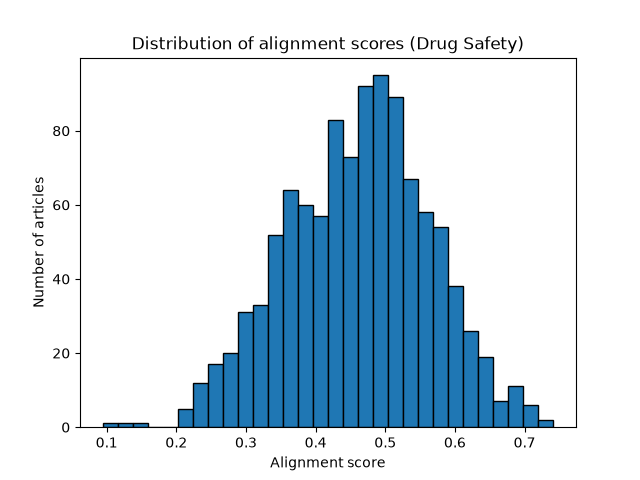

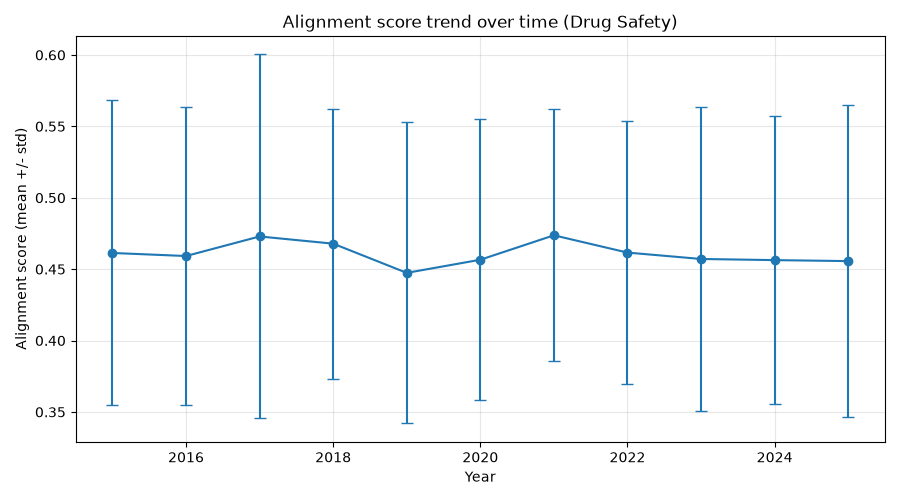

In [37]:
figure_names = [
    "score_distribution_check.png",
    "score_trend_by_year.png",
]

for name in figure_names:
    path = FIGURES_DIR / name
    if path.exists():
        display(Image(filename=str(path), width=500))
    else:
        print(f"{name}: not found — run the corresponding script first.")

## 7. Chunking check

Most Drug Safety abstracts exceed the embedding model's token limit (see
EDA). This confirms how often the sentence-based chunking
in `model_interface.py` actually kicks in on the real corpus.

In [38]:
chunk_report = pd.read_csv(TABLES_DIR / "chunk_count_report.csv")
multi_chunk = (chunk_report["n_chunks"] > 1).sum()
print(f"{multi_chunk} out of {len(chunk_report)} abstracts "
      f"({100 * multi_chunk / len(chunk_report):.1f}%) needed more than 1 chunk")
print(f"Max chunks for a single abstract: {chunk_report['n_chunks'].max()}")
display(preview(chunk_report, ["pmid", "year", "abstract_length_chars", "n_chunks"], rows=5))

991 out of 1074 abstracts (92.3%) needed more than 1 chunk
Max chunks for a single abstract: 5


,pmid,year,n_chunks
0,40952627,2025,1
1,40900408,2025,2
2,40835783,2025,2
3,40762949,2025,2
4,40745250,2025,3


## 8. Naive BERT vs SentenceTransformer

`src/bert_comparison.py` compares raw BERT (mean-pooling over token vectors,
via `transformers`) against our official SentenceTransformer method, on a
sample of 250 articles (sample size chosen following Schönbrodt & Perugini,
2013, for a stable correlation estimate). Not re-run here
(downloads a second model, several minutes).
Results:

| Metric | SentenceTransformer | Naive BERT |
|---|---|---|
| Mean | 0.461 | 0.841 |
| Std | 0.100 | 0.025 |

Correlation between the two methods: r = 0.339 (p < 0.001), moderate,
far from perfect agreement.



## 9. BERTopic

`src/topic_analysis.py` identifies 23 thematic topics together with a noise cluster using BERTopic, reusing the same SentenceTransformer embeddings computed for the alignment analysis. English stopwords are removed only from the keyword representation step for readability.

The full topic summary is shown below.

In [39]:
topic_summary = pd.read_csv(TABLES_DIR / "topic_summary.csv")
display(topic_summary)

,topic,count,mean_score,diff_from_overall,keywords
0,-1,300,0.490847,0.029965,(noise)
1,0,118,0.416302,-0.044579,"patients, treatment, events, inhibitors, adverse"
2,1,78,0.408560,-0.052322,"pregnancy, exposure, women, pregnancies, outcomes"
3,2,75,0.343876,-0.117005,"vaccine, covid19, vaccines, vaccination, dose"
4,3,49,0.480692,0.019811,"95, ci, risk, use, antidepressants"
...,...,...,...,...,...
20,19,14,0.490345,0.029464,"herbal, products, medicinal, species, dna"
21,20,14,0.458554,-0.002327,"art, patients, hiv, adrs, prep"
22,21,14,0.386386,-0.074495,"iron, asthma, copd, ferric, carboxymaltose"
23,22,10,0.552125,0.091243,"minimization, evaluation, programs, implementation, program"


## 10. Topic evolution over time

Although the aggregate alignment score remains relatively stable over time, this does not necessarily imply that the thematic composition of the journal is equally stable. To explore possible changes within individual areas, we examine how the prevalence of the BERTopic clusters evolves across years.

The heatmap below shows the annual frequency of all non-noise topics. Each row is normalized independently, making it possible to observe changes within each topic regardless of differences in their absolute size.

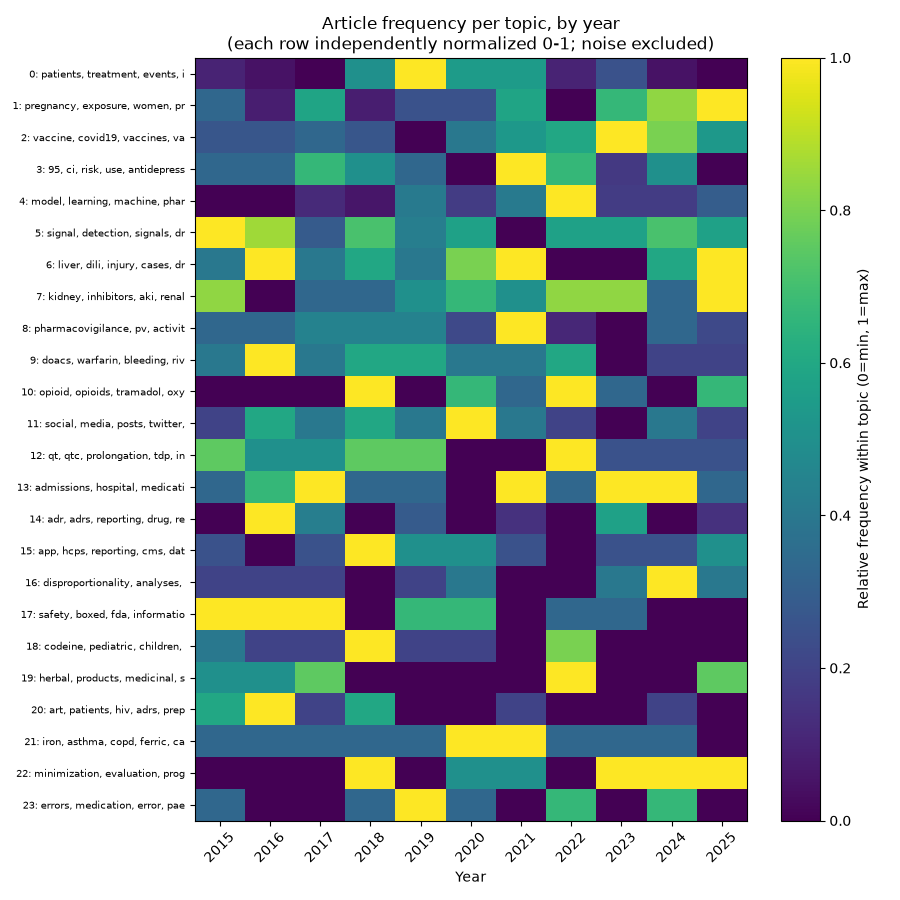

In [40]:
topic_heatmap = FIGURES_DIR / "all_topics_over_time_heatmap.png"

if topic_heatmap.exists():
    display(Image(filename=str(topic_heatmap), width=850))
else:
    print("Heatmap not found, run src/topic_analysis.py first.")

The heatmap reveals that the stable aggregate alignment can coexist with changes in the prevalence of individual themes. As an illustrative example, we focus on Topic 4, which captures AI and machine-learning methodology and is particularly relevant to the earlier qualitative analysis, where AI-related articles appeared among the least-aligned cases.

The figure below shows the annual frequency of Topic 4 in detail.

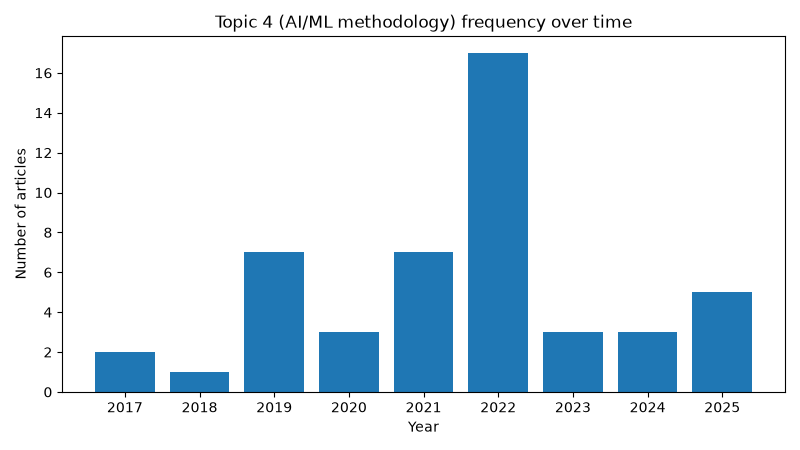

In [41]:
topic_time_chart = FIGURES_DIR / "topic4_frequency_over_time.png"

if topic_time_chart.exists():
    display(Image(filename=str(topic_time_chart), width=600))
else:
    print("Chart not found, run src/topic_analysis.py first.")